In [568]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    recall_score,
    f1_score,
    precision_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import shap

# loading & cheking data

In [569]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [570]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [571]:
df.shape

(7043, 21)

In [572]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# removing Unnecessary fetures

In [573]:
df=df.drop(["customerID"], axis=1) # also we can write df=df.drop(columns=['customerID'])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploring Unique values categorical columns

In [574]:
fetures = ["tenure","MonthlyCharges","TotalCharges"]
for col in df.columns :
  if col not in fetures :
    print(col,df[col].unique())

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


# checking for missing values

In [575]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [576]:
df["TotalCharges"].values #Python sees this value as a string (text), not a number!

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [577]:
df[df["TotalCharges"] == " "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [578]:
len(df[df["TotalCharges"] == " "])

11

In [579]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", 0.0)

df["TotalCharges"] = df["TotalCharges"].astype(float) # Convert column data type from string (object) to float (numeric)

In [580]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Visualizing churn distribution

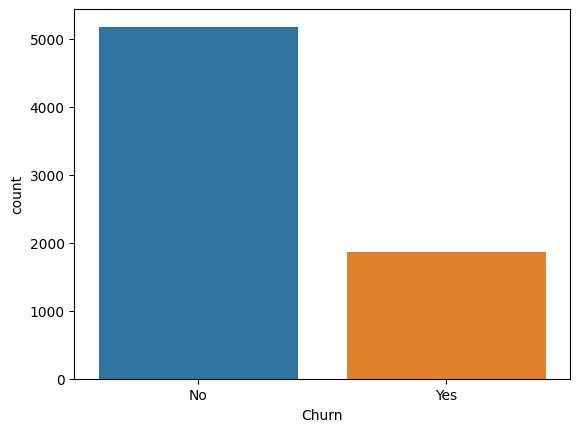

In [581]:
sns.countplot(data=df, x="Churn",hue="Churn") #hue means when group change color change
plt.show()

In [641]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [582]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


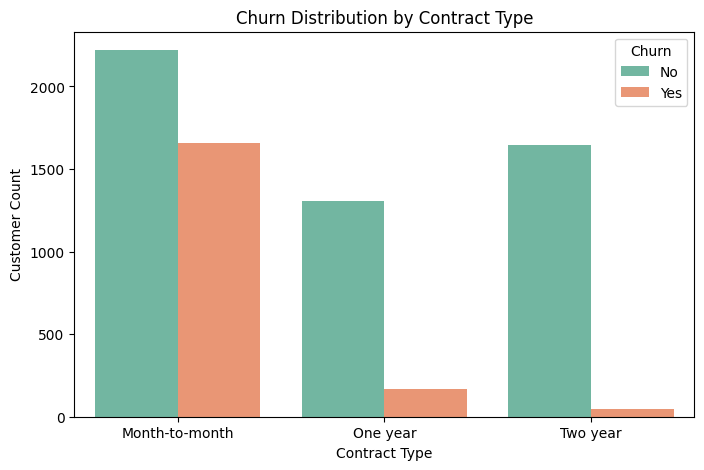

In [583]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set2")
plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.show()

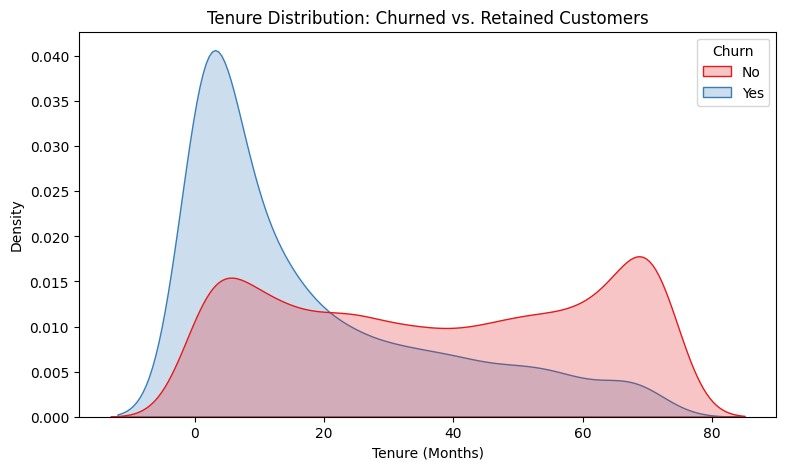

In [584]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="tenure", hue="Churn", common_norm=False, fill=True, palette="Set1")
plt.title("Tenure Distribution: Churned vs. Retained Customers")
plt.xlabel("Tenure (Months)")
plt.show()

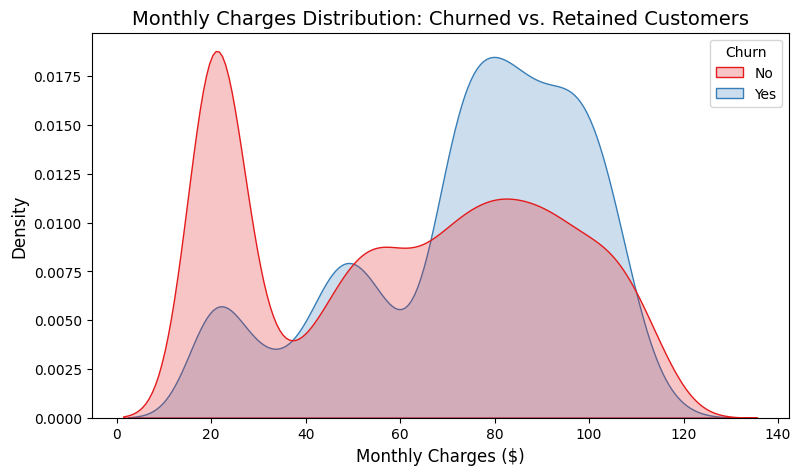

In [585]:
plt.figure(figsize=(9, 5)) #figsize = (width, height)
sns.kdeplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    fill=True,
    common_norm=False,
    palette="Set1"
)

plt.title("Monthly Charges Distribution: Churned vs. Retained Customers", fontsize=14)
plt.xlabel("Monthly Charges ($)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.show()

/tmp/ipykernel_2972/3199820914.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="Set3")


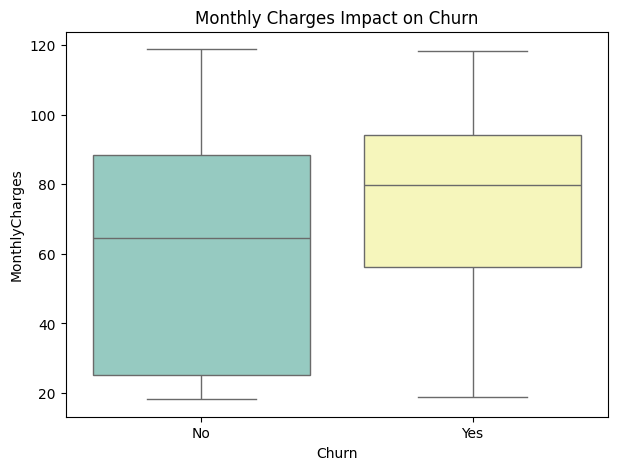

In [586]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette="Set3")
plt.title("Monthly Charges Impact on Churn")
plt.show()

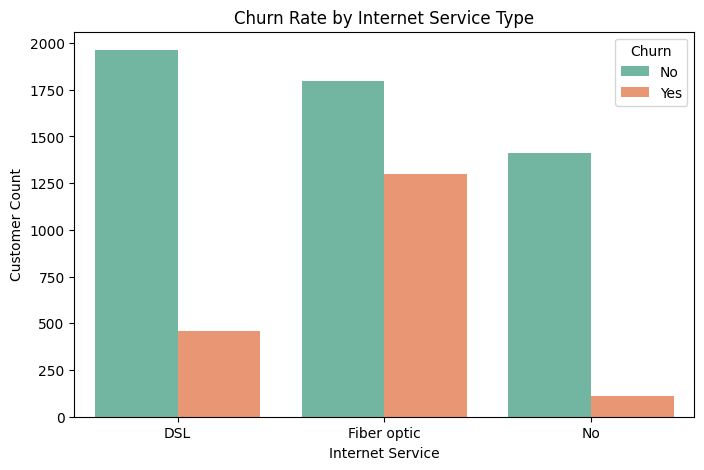

In [587]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="InternetService", hue="Churn", palette="Set2")
plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")
plt.show()

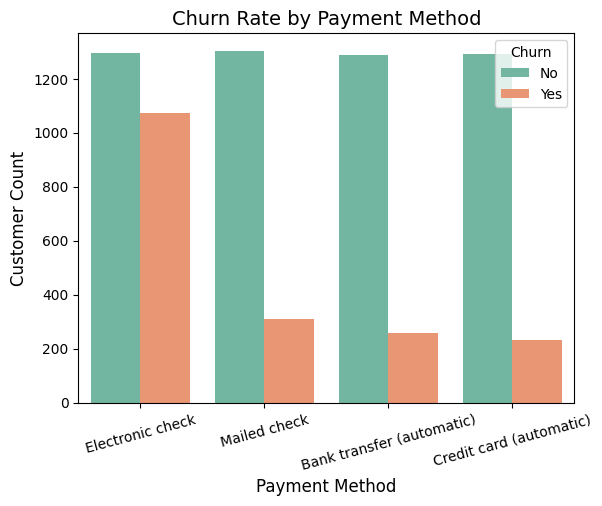

In [588]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="Set2"
)
plt.title("Churn Rate by Payment Method", fontsize=14)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Customer Count", fontsize=12)
plt.xticks(rotation=15) # because not mix texts


plt.show()

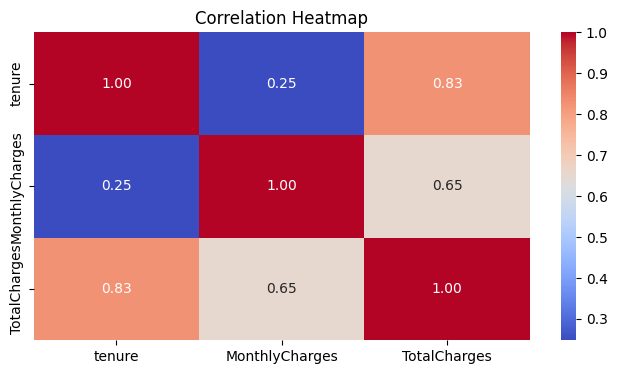

In [589]:
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# cleaning categorical columns for consistency

In [590]:
# Replacing 'No phone service' --> No
# Replacing 'No internet service' --> No
df.replace({'No internet service': 'No', 'No phone service': 'No'}, inplace=True)

# Encoding binary(yes\no) columns to binary

In [591]:
yes_no_columns = ["Partner","Dependents","PhoneService","MultipleLines",'OnlineSecurity',"OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","PaperlessBilling","Churn"]
le = LabelEncoder()
for col in yes_no_columns:
    df[col] = le.fit_transform(df[col])

In [592]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


# Encoding multi-categorical varibles Using One-Hot Encoding

In [593]:
df2 = pd.get_dummies(data=df, columns=["InternetService", "Contract", "PaymentMethod"], dtype=int)
df2.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,Female,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,Male,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,Male,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
3,Male,0,0,0,45,0,0,1,0,1,...,1,0,0,0,1,0,1,0,0,0
4,Female,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [594]:
le = LabelEncoder()
# Fit and transform the gender column
df2["gender"] = le.fit_transform(df2["gender"])

In [595]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

In [596]:
X = df2.drop(columns=['Churn'])
y = df2['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,0.102371,0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
3151,1,0,1,1,-0.711743,1,0,1,0,0,...,0,1,0,1,0,0,0,0,0,1
4860,1,0,1,1,-0.793155,0,0,1,1,0,...,1,0,0,0,0,1,0,0,0,1
3867,0,0,1,0,-0.263980,1,0,0,1,1,...,1,0,0,0,0,1,0,1,0,0
3810,1,0,1,1,-1.281624,1,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0


# **

In [597]:
smote =SMOTE(random_state=42)
X_train_smote,y_train_smote =smote.fit_resample(X_train,y_train)

In [598]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Logistic regression model

In [599]:
logistic_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [600]:
y_pred_logistic = logistic_model.predict(X_test)

In [601]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("=" * 40)
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1 Score :", f1_logistic)

Logistic Regression Results
Accuracy : 0.7629524485450674
Precision: 0.5396825396825397
Recall   : 0.7272727272727273
F1 Score : 0.6195899772209568


In [602]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



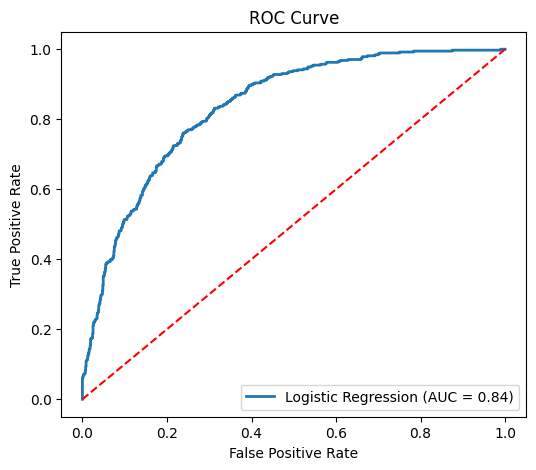

In [603]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})",
    linewidth=2
)

plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [604]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[803 232]
 [102 272]]


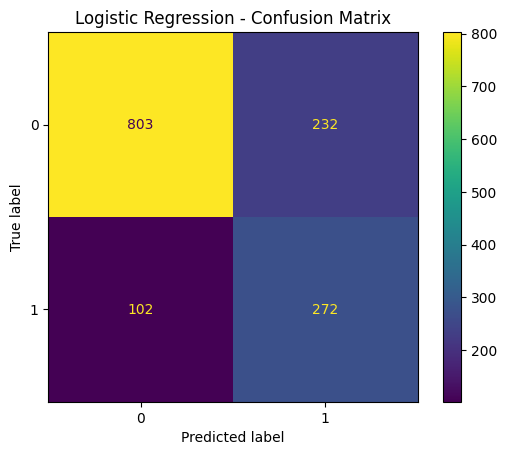

In [605]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=logistic_model.classes_
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [606]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_logistic,
    "Precision": precision_logistic,
    "Recall": recall_logistic,
    "F1 Score": f1_logistic
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7629524485450674,
 'Precision': 0.5396825396825397,
 'Recall': 0.7272727272727273,
 'F1 Score': 0.6195899772209568}

# Decision Tree Model

In [607]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [608]:
y_pred_dt = dt_model.predict(X_test)

# Prediction probabilities
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [609]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.7508871540099361
Precision: 0.5217391304347826
Recall   : 0.7379679144385026
F1 Score : 0.6112956810631229
ROC AUC  : 0.8286587098607558

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



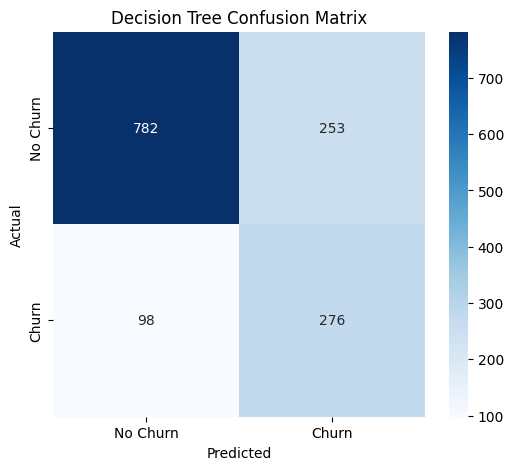

In [610]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn','Churn'],
    yticklabels=['No Churn','Churn']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

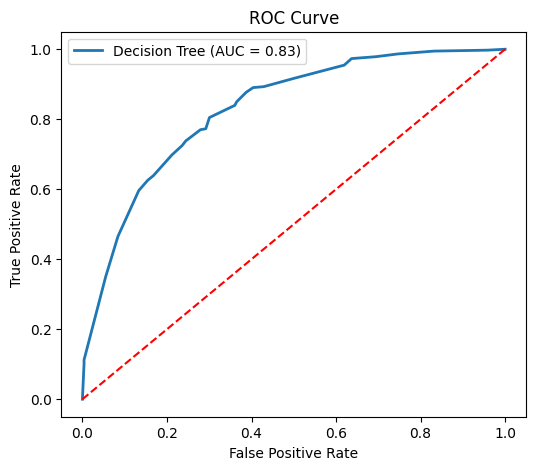

In [611]:


y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC = {roc_auc_dt:.2f})",
    linewidth=2
)

plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [612]:
importance = dt_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
19,Contract_Month-to-month,0.542935
4,tenure,0.123325
17,InternetService_Fiber optic,0.098697
20,Contract_One year,0.059626
14,MonthlyCharges,0.046860
21,Contract_Two year,0.040880
7,OnlineSecurity,0.023821
10,TechSupport,0.013842
18,InternetService_No,0.012613
5,PhoneService,0.012093


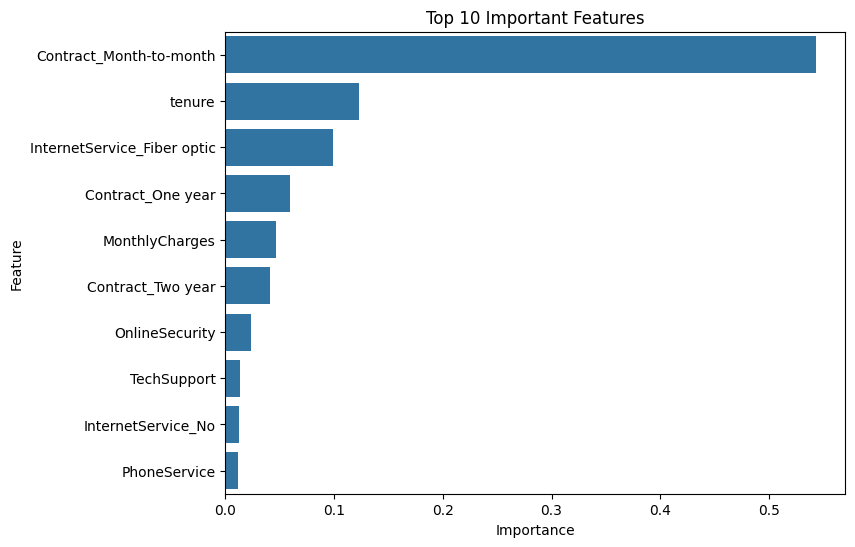

In [613]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

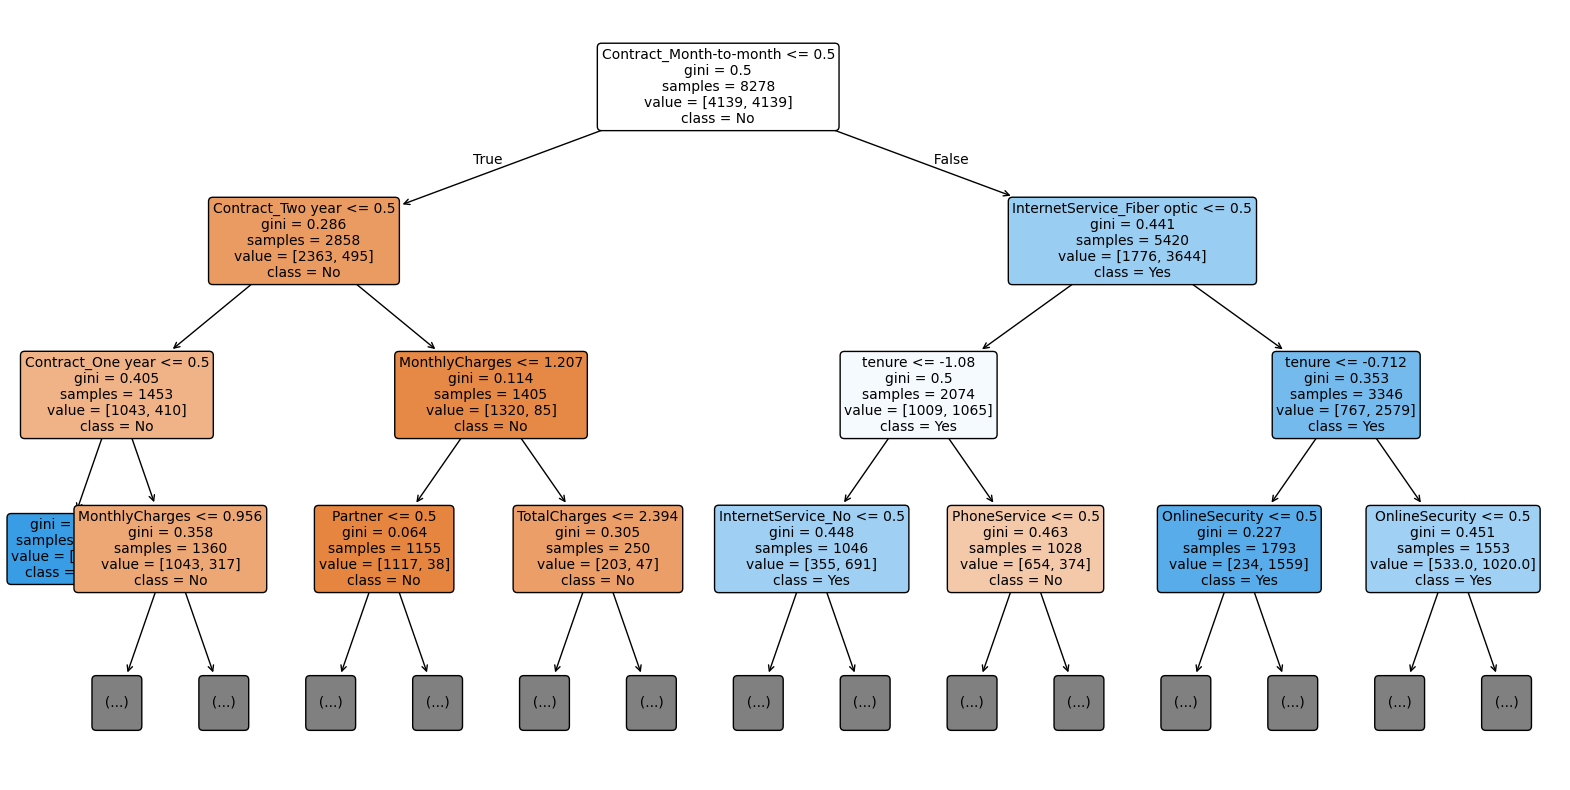

In [614]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.show()

In [615]:
sample = X_test.iloc[[0]]

prediction = dt_model.predict(sample)[0]
probability = dt_model.predict_proba(sample)[0][1]

print("Prediction:", "Churn" if prediction==1 else "No Churn")
print("Probability:", round(probability*100,2),"%")

Prediction: No Churn
Probability: 0.0 %


In [616]:
print(importance_df.head(10))

                        Feature  Importance
19      Contract_Month-to-month    0.542935
4                        tenure    0.123325
17  InternetService_Fiber optic    0.098697
20            Contract_One year    0.059626
14               MonthlyCharges    0.046860
21            Contract_Two year    0.040880
7                OnlineSecurity    0.023821
10                  TechSupport    0.013842
18           InternetService_No    0.012613
5                  PhoneService    0.012093


# Random Forest Model

In [617]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [618]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [619]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7636621717530163
Precision: 0.539651837524178
Recall   : 0.7459893048128342
F1 Score : 0.6262626262626263
ROC AUC  : 0.842744581363507

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



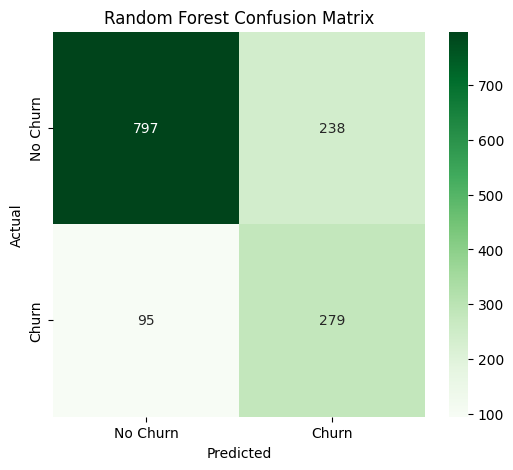

In [620]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

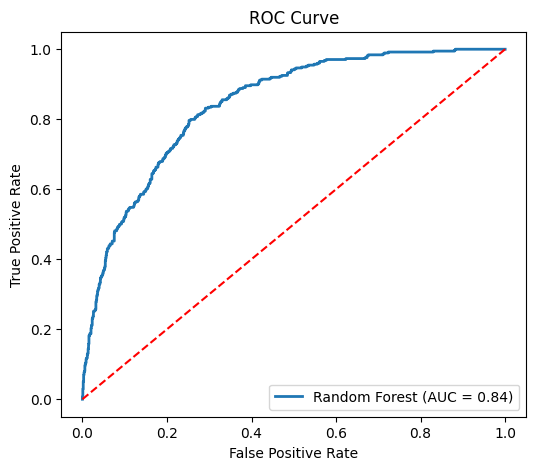

In [621]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc_rf:.2f})",
    linewidth=2
)

plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [622]:
importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
19,Contract_Month-to-month,0.163232
4,tenure,0.138827
14,MonthlyCharges,0.106739
15,TotalCharges,0.088759
21,Contract_Two year,0.077571
17,InternetService_Fiber optic,0.070347
7,OnlineSecurity,0.046887
18,InternetService_No,0.041135
24,PaymentMethod_Electronic check,0.039028
10,TechSupport,0.032775


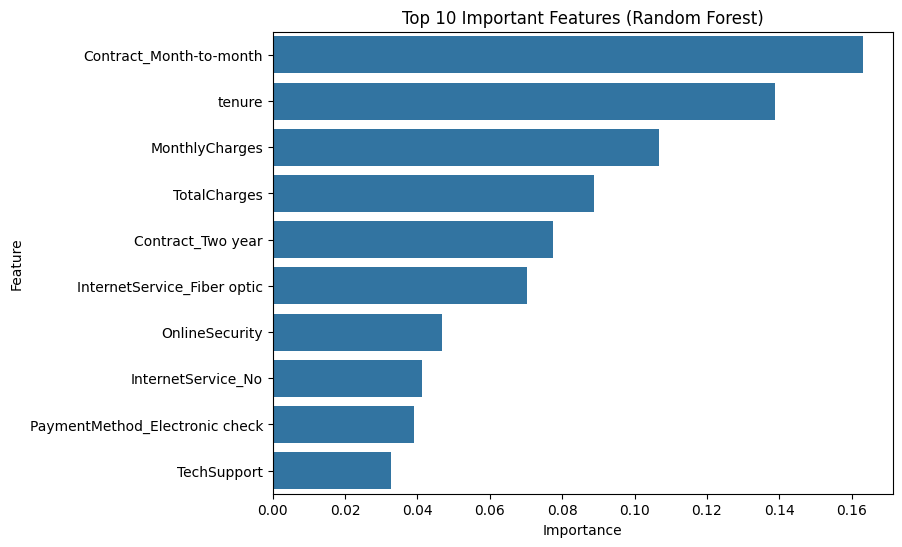

In [623]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features (Random Forest)")

plt.show()

In [624]:
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)[0]

probability = rf_model.predict_proba(sample)[0][1]

print("Prediction :", "Churn" if prediction==1 else "No Churn")

print("Probability :", round(probability*100,2),"%")

Prediction : No Churn
Probability : 0.95 %


In [625]:
print(importance.head(10))

                           Feature  Importance
19         Contract_Month-to-month    0.163232
4                           tenure    0.138827
14                  MonthlyCharges    0.106739
15                    TotalCharges    0.088759
21               Contract_Two year    0.077571
17     InternetService_Fiber optic    0.070347
7                   OnlineSecurity    0.046887
18              InternetService_No    0.041135
24  PaymentMethod_Electronic check    0.039028
10                     TechSupport    0.032775


In [626]:
risk = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf,
    "Churn Probability": y_prob_rf
})

risk = risk.sort_values(
    by="Churn Probability",
    ascending=False
)

risk.head(10)

,Actual,Predicted,Churn Probability
1109,1,1,0.950424
1221,1,1,0.949517
341,1,1,0.946411
629,0,1,0.944844
1252,1,1,0.944844
1289,1,1,0.943900
618,1,1,0.941332
171,1,1,0.938674
740,1,1,0.937155
1259,1,1,0.934566


In [627]:
risk["Risk Level"] = pd.cut(
    risk["Churn Probability"],
    bins=[0,0.4,0.7,1],
    labels=["Low","Medium","High"]
)

risk.head(10)

,Actual,Predicted,Churn Probability,Risk Level
1109,1,1,0.950424,High
1221,1,1,0.949517,High
341,1,1,0.946411,High
629,0,1,0.944844,High
1252,1,1,0.944844,High
1289,1,1,0.943900,High
618,1,1,0.941332,High
171,1,1,0.938674,High
740,1,1,0.937155,High
1259,1,1,0.934566,High


# XG BOOST Model

In [628]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [629]:
y_pred_xgb = xgb_model.predict(X_test)

In [630]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7558552164655784

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

Confusion Matrix:
[[782 253]
 [ 91 283]]


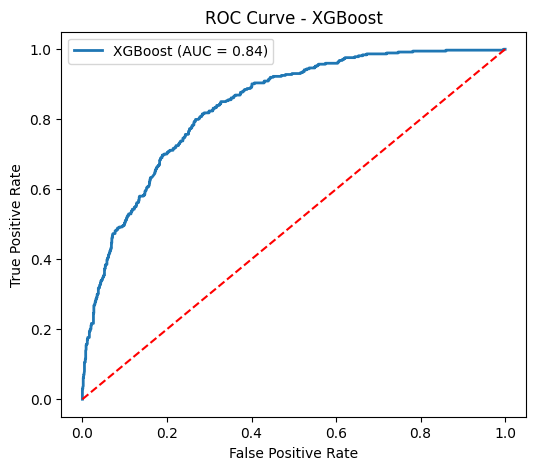

In [631]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

# Calculate ROC-AUC
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Plot
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc_xgb:.2f})",
    linewidth=2
)

# Random Classifier
plt.plot(
    [0, 1],
    [0, 1],
    'r--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

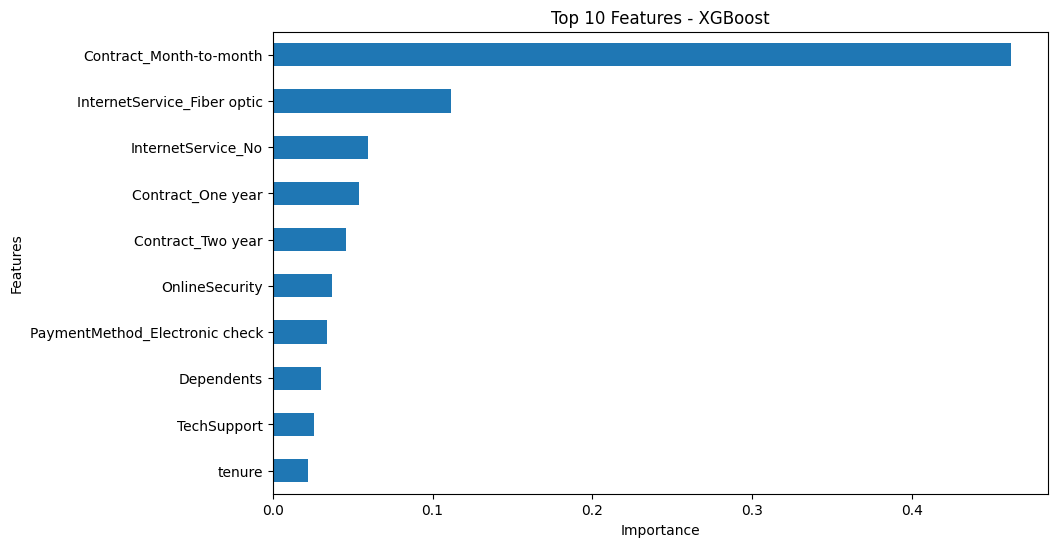

In [632]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

feature_importance.tail(10).plot(kind="barh")

plt.title("Top 10 Features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

# The Comparison

In [633]:
# Dictionary to store all models
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# Store results
results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Create DataFrame
results_df = pd.DataFrame(results)

# Sort models by F1-Score
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

# Display results
print("Model Comparison:")
display(results_df)

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.763662,0.539652,0.745989,0.626263,0.842745
1,XGBoost,0.755855,0.527985,0.756684,0.621978,0.839292
2,Logistic Regression,0.762952,0.539683,0.727273,0.619590,0.835746
3,Decision Tree,0.750887,0.521739,0.737968,0.611296,0.828659


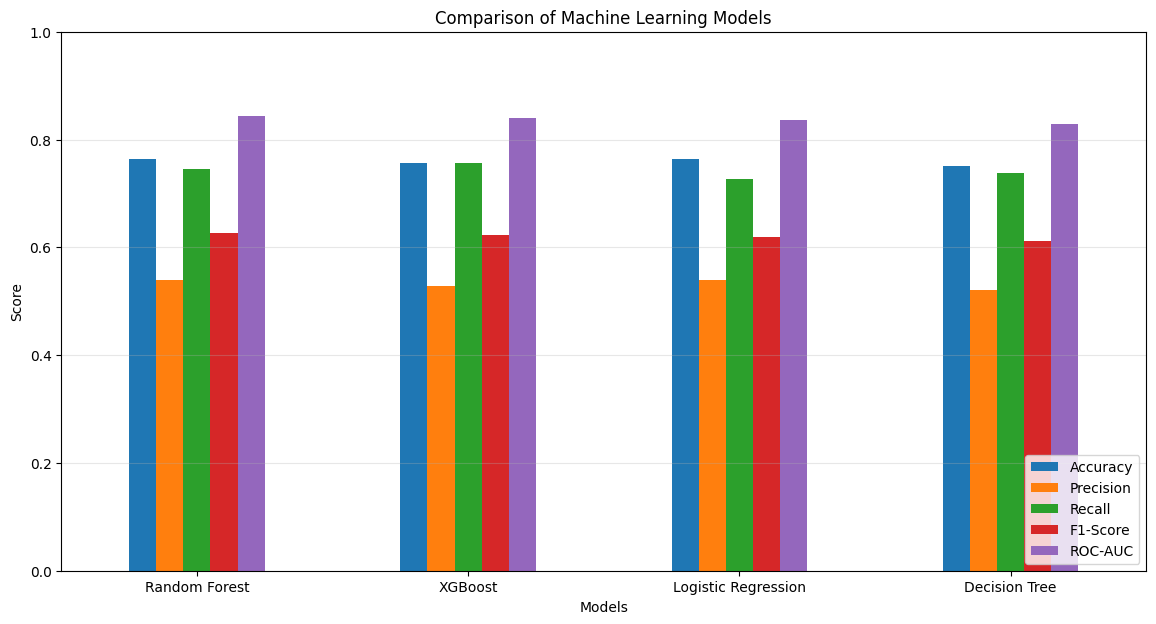

In [634]:
# Plot model comparison

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)

plt.show()

# The Best Model

In [635]:
# choose best model based on Recall (XGBoost)
best_model_row = results_df.loc[results_df["Recall"].idxmax()]

best_model_name = best_model_row["Model"]
best_recall_score = best_model_row["Recall"]

print(f"🏆 Best Model Selected (Optimized for Churn Recall): {best_model_name}")
print(f"🎯 Best Recall Score: {best_recall_score:.4f}\n")
print("--- Selected Model Summary Performance ---")
print(best_model_row)

🏆 Best Model Selected (Optimized for Churn Recall): XGBoost
🎯 Best Recall Score: 0.7567

--- Selected Model Summary Performance ---
Model         XGBoost
Accuracy     0.755855
Precision    0.527985
Recall       0.756684
F1-Score     0.621978
ROC-AUC      0.839292
Name: 1, dtype: object


In [636]:
print("Best Accuracy Model:")
print(results_df.loc[results_df["Accuracy"].idxmax(), ["Model", "Accuracy"]])

print("\nBest Precision Model:")
print(results_df.loc[results_df["Precision"].idxmax(), ["Model", "Precision"]])

print("\nBest Recall Model:")
print(results_df.loc[results_df["Recall"].idxmax(), ["Model", "Recall"]])

print("\nBest F1-Score Model:")
print(results_df.loc[results_df["F1-Score"].idxmax(), ["Model", "F1-Score"]])

print("\nBest ROC-AUC Model:")
print(results_df.loc[results_df["ROC-AUC"].idxmax(), ["Model", "ROC-AUC"]])

Best Accuracy Model:
Model       Random Forest
Accuracy         0.763662
Name: 0, dtype: object

Best Precision Model:
Model        Logistic Regression
Precision               0.539683
Name: 2, dtype: object

Best Recall Model:
Model      XGBoost
Recall    0.756684
Name: 1, dtype: object

Best F1-Score Model:
Model       Random Forest
F1-Score         0.626263
Name: 0, dtype: object

Best ROC-AUC Model:
Model      Random Forest
ROC-AUC         0.842745
Name: 0, dtype: object


In [637]:
import joblib


joblib.dump(xgb_model, 'xgb_model.pkl')


joblib.dump(scaler, 'scaler.pkl')


joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')


print("- xgb_model.pkl")
print("- scaler.pkl")
print("- model_columns.pkl")

- xgb_model.pkl
- scaler.pkl
- model_columns.pkl


# Advanced Features & Business Intelligence

**CLV & Risk Segmentation**

In [638]:
# Append prediction probabilities and segment customers based on churn risk
X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_test_df['Churn_Probability'] = y_prob

def assign_risk_segment(prob):
    """Categorizes customers into risk tiers based on churn probability."""
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

X_test_df['Risk_Segment'] = X_test_df['Churn_Probability'].apply(assign_risk_segment)

# Calculate Customer Lifetime Value (CLV) estimation
# Assuming tenure and MonthlyCharges are present in features
if 'tenure' in X_test_df.columns and 'MonthlyCharges' in X_test_df.columns:
    X_test_df['Estimated_Lifespan_Months'] = X_test_df['tenure'] * 1.5
    X_test_df['CLV'] = X_test_df['MonthlyCharges'] * X_test_df['Estimated_Lifespan_Months']

print(X_test_df[['Churn_Probability', 'Risk_Segment', 'CLV']].head(10))

      Churn_Probability Risk_Segment       CLV
437            0.018760     Low Risk  3.932685
2280           0.873465    High Risk -1.747274
2235           0.110520     Low Risk  0.231528
4460           0.566817  Medium Risk -0.389460
3761           0.017841     Low Risk  1.418715
5748           0.815406    High Risk -0.812603
3568           0.690338  Medium Risk -0.796314
2976           0.105508     Low Risk  1.115584
5928           0.027927     Low Risk -2.610281
1639           0.590019  Medium Risk  0.623733


**Explainable AI (SHAP) & Automated Retention Actions**

In [639]:
# Initialize SHAP explainer to interpret individual customer predictions
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

def determine_retention_action(row):
    """Determines automated business intervention based on CLV and Churn Risk."""
    prob = row['Churn_Probability']
    clv = row.get('CLV', 0)

    if prob > 0.6 and clv > 2000:
        return "Action: Send High-Value Retention Discount (20% Off)"
    elif prob > 0.6:
        return "Action: Send Standard Engagement Survey"
    else:
        return "Action: No Action Required"

# Apply automated business logic rules
X_test_df['Recommended_Action'] = X_test_df.apply(determine_retention_action, axis=1)

# Display final integrated decision-making table
print(X_test_df[['Churn_Probability', 'Risk_Segment', 'CLV', 'Recommended_Action']].head())

      Churn_Probability Risk_Segment       CLV  \
437            0.018760     Low Risk  3.932685   
2280           0.873465    High Risk -1.747274   
2235           0.110520     Low Risk  0.231528   
4460           0.566817  Medium Risk -0.389460   
3761           0.017841     Low Risk  1.418715   

                           Recommended_Action  
437                Action: No Action Required  
2280  Action: Send Standard Engagement Survey  
2235               Action: No Action Required  
4460               Action: No Action Required  
3761               Action: No Action Required  


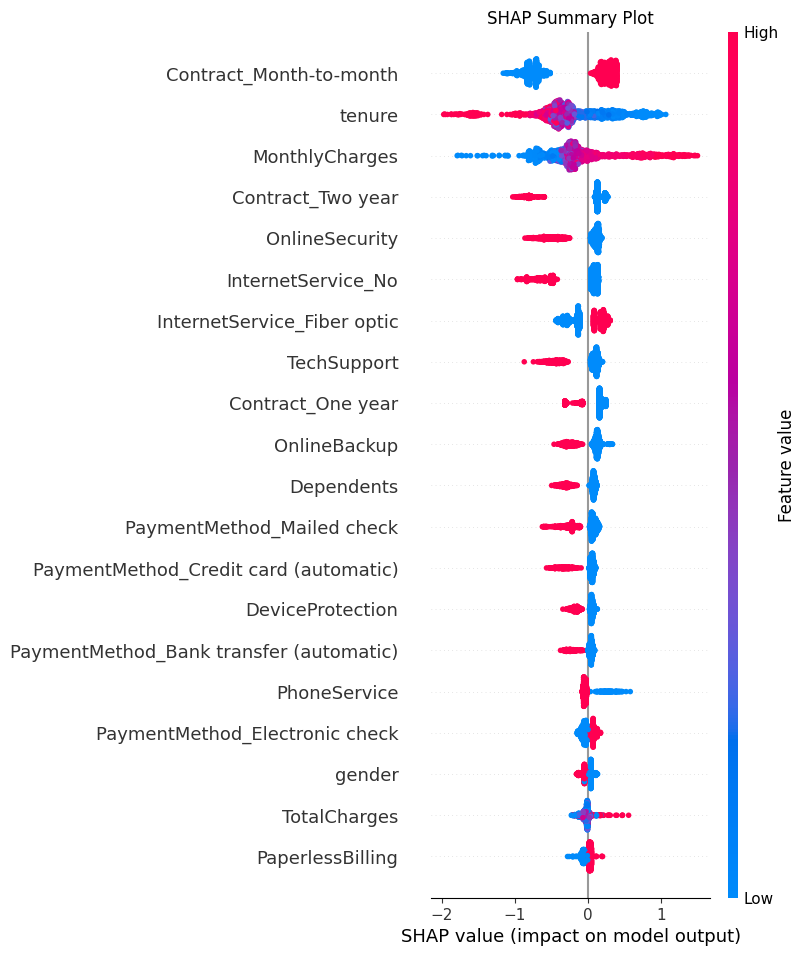

In [640]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.show()